**Week 1**

*Files merged by Pearl Osong, cleaned by Staicy Kimberly*

In [29]:
import pandas as pd

# 1. Load the datasets
ratings = pd.read_csv("C:\\Users\\PAUL\\Downloads\\archive\\ratings_small.csv")
movies = pd.read_csv("C:\\Users\\PAUL\\Downloads\\archive\\movies_metadata.csv", low_memory=False)

print("Ratings loaded:", ratings.shape)
print("Movies loaded:", movies.shape)

Ratings loaded: (100004, 4)
Movies loaded: (45466, 24)


In [30]:

# 2. Clean and convert 'id' column in movies
movies['id'] = pd.to_numeric(movies['id'], errors='coerce')
movies = movies.dropna(subset=['id'])
movies['id'] = movies['id'].astype(int)

In [31]:
# 3. Rename columns and format timestamps
movies.rename(columns={'id': 'movieId'}, inplace=True)
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')


In [32]:
# 4. Fill missing values (Updated to avoid FutureWarnings)
movies['title'] = movies['title'].fillna("Unknown")
movies['overview'] = movies['overview'].fillna("No description")
movies['runtime'] = movies['runtime'].fillna(movies['runtime'].mean())


In [33]:
# 5. Remove duplicates and merge datasets
movies.drop_duplicates(subset=['movieId'], inplace=True)
df = pd.merge(ratings, movies, on='movieId', how='inner')


In [34]:
# 6. Preview and Save
print("Merged DataFrame shape:", df.shape)
print(df.head())

Merged DataFrame shape: (44989, 27)
   userId  movieId  rating           timestamp  adult  \
0       1     1371     2.5 2009-12-14 02:52:15  False   
1       1     1405     1.0 2009-12-14 02:53:23  False   
2       1     2105     4.0 2009-12-14 02:52:19  False   
3       1     2193     2.0 2009-12-14 02:53:18  False   
4       1     2294     2.0 2009-12-14 02:51:48  False   

                               belongs_to_collection    budget  \
0  {'id': 1575, 'name': 'Rocky Collection', 'post...  17000000   
1                                                NaN    546883   
2  {'id': 2806, 'name': 'American Pie Collection'...  11000000   
3                                                NaN         0   
4                                                NaN  22000000   

                                              genres  \
0                      [{'id': 18, 'name': 'Drama'}]   
1  [{'id': 18, 'name': 'Drama'}, {'id': 36, 'name...   
2  [{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...   


In [35]:
df.to_excel("final_movie_data.xlsx", index=False)

**Week 2**

*Done by Peris Kasyoki and Joy Migwi*

In [36]:
import pandas as pd

# Load the Excel file
df = pd.read_excel(r"C:\Users\PAUL\Documents\final_movie_data.xlsx")

# Save it as CSV
df.to_csv("final_movie_data.csv", index=False)
print(df)


       userId  movieId  rating           timestamp  adult  \
0           1     1371     2.5 2009-12-14 02:52:15  False   
1           1     1405     1.0 2009-12-14 02:53:23  False   
2           1     2105     4.0 2009-12-14 02:52:19  False   
3           1     2193     2.0 2009-12-14 02:53:18  False   
4           1     2294     2.0 2009-12-14 02:51:48  False   
...       ...      ...     ...                 ...    ...   
44984     671     4995     4.0 2003-09-30 03:12:17  False   
44985     671     5816     4.0 2003-10-02 16:26:03  False   
44986     671     5902     3.5 2003-09-22 15:45:07  False   
44987     671     5991     4.5 2003-09-22 15:43:07  False   
44988     671     5995     4.0 2003-10-22 03:23:34  False   

                                   belongs_to_collection    budget  \
0      {'id': 1575, 'name': 'Rocky Collection', 'post...  17000000   
1                                                    NaN    546883   
2      {'id': 2806, 'name': 'American Pie Collection'... 

In [37]:
#dropping unnecessary columns
columns_to_remove = ["belongs_to_collection", "homepage", "imdb_id", "overview", "poster_path", "spoken_languages", "tagline", "original_title","video"]
df_cleaned = df.drop(columns=columns_to_remove)
print(df_cleaned)

       userId  movieId  rating           timestamp  adult    budget  \
0           1     1371     2.5 2009-12-14 02:52:15  False  17000000   
1           1     1405     1.0 2009-12-14 02:53:23  False    546883   
2           1     2105     4.0 2009-12-14 02:52:19  False  11000000   
3           1     2193     2.0 2009-12-14 02:53:18  False         0   
4           1     2294     2.0 2009-12-14 02:51:48  False  22000000   
...       ...      ...     ...                 ...    ...       ...   
44984     671     4995     4.0 2003-09-30 03:12:17  False  15000000   
44985     671     5816     4.0 2003-10-02 16:26:03  False         0   
44986     671     5902     3.5 2003-09-22 15:45:07  False  22000000   
44987     671     5991     4.5 2003-09-22 15:43:07  False         0   
44988     671     5995     4.0 2003-10-22 03:23:34  False         0   

                                                  genres original_language  \
0                          [{'id': 18, 'name': 'Drama'}]             

In [38]:
column_names = df_cleaned.columns.tolist()
print(column_names)

['userId', 'movieId', 'rating', 'timestamp', 'adult', 'budget', 'genres', 'original_language', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'status', 'title', 'vote_average', 'vote_count']


In [39]:
#renaming the columns
df_cleaned.rename(columns={"userId":"User ID", "movieId":"Movie ID", "rating":"Rating", "timestamp":"Timestamp", "adult":"Adult","budget":"Budget", "genres":"Genres","original_language":"Original_language","popularity":"Popularity","production_companies":"Production_companies",
                    "production_countries":"Production_countries", "release_date":"Release_date", "revenue":"Revenue", "runtime":"Runtime", "status":"Status", "title":"Title", "vote_average":"Vote_average","vote_count":"Vote_count"
                    }, inplace=True)
column_names = df_cleaned.columns.tolist()
print(column_names)

['User ID', 'Movie ID', 'Rating', 'Timestamp', 'Adult', 'Budget', 'Genres', 'Original_language', 'Popularity', 'Production_companies', 'Production_countries', 'Release_date', 'Revenue', 'Runtime', 'Status', 'Title', 'Vote_average', 'Vote_count']


In [40]:
#2. Handle missing values
#check for missing values
print(df_cleaned.isnull().sum())

User ID                  0
Movie ID                 0
Rating                   0
Timestamp                0
Adult                    0
Budget                   0
Genres                   0
Original_language        0
Popularity               0
Production_companies     0
Production_countries     0
Release_date            29
Revenue                  0
Runtime                  0
Status                   1
Title                    0
Vote_average             0
Vote_count               0
dtype: int64


In [41]:
#remove missing values
df_cleaned = df_cleaned.dropna()
print(df_cleaned.isnull().sum())

User ID                 0
Movie ID                0
Rating                  0
Timestamp               0
Adult                   0
Budget                  0
Genres                  0
Original_language       0
Popularity              0
Production_companies    0
Production_countries    0
Release_date            0
Revenue                 0
Runtime                 0
Status                  0
Title                   0
Vote_average            0
Vote_count              0
dtype: int64


In [42]:
#3. check for duplicates
print(df_cleaned.duplicated().sum())

0


In [43]:
#4.correcting data types
df_cleaned["Movie ID"] = df_cleaned["Movie ID"].astype(str)
df_cleaned["User ID"] = df_cleaned["User ID"].astype(str)
df_cleaned["Rating"] = df_cleaned["Rating"].astype(float)
df_cleaned["Timestamp"] = df_cleaned["Timestamp"].astype(int)
df_cleaned["Budget"] = df_cleaned["Budget"].astype(int)
df_cleaned["Popularity"] = df_cleaned["Popularity"].astype(float)
df_cleaned["Revenue"] = df_cleaned["Revenue"].astype(float)
df_cleaned["Runtime"] = df_cleaned["Runtime"].astype(float)
df_cleaned["Vote_average"] = df_cleaned["Vote_average"].astype(float)
df_cleaned["Vote_count"] = df_cleaned["Vote_count"].astype(int)
print(df_cleaned.dtypes)

User ID                     str
Movie ID                    str
Rating                  float64
Timestamp                 int64
Adult                      bool
Budget                    int64
Genres                      str
Original_language           str
Popularity              float64
Production_companies        str
Production_countries        str
Release_date                str
Revenue                 float64
Runtime                 float64
Status                      str
Title                       str
Vote_average            float64
Vote_count                int64
dtype: object


In [44]:
#convert data columns
df_cleaned["Release_date"] = pd.to_datetime(df_cleaned["Release_date"])
print(df_cleaned["Release_date"])

0       1982-05-28
1       1924-12-04
2       1999-07-09
3       1983-03-04
4       2001-08-22
           ...    
44984   1997-09-11
44985   2006-09-28
44986   1977-06-15
44987   1924-12-23
44988   2003-07-31
Name: Release_date, Length: 44959, dtype: datetime64[us]



**Week 3**

In [45]:
# total unique movies
total_movies = df_cleaned['Title'].nunique()
print(f"Total Unique Movies: {total_movies}")

Total Unique Movies: 2792


In [46]:
# average user rating
avg_user_rating = df_cleaned['Rating'].mean()
print(f"Average Movie Rating: {avg_user_rating:.2f}")

Average Movie Rating: 3.56


In [47]:
# Newesr and oldes movies
oldest_year = df_cleaned['Release_date'].dt.year.min()
newest_year = df_cleaned['Release_date'].dt.year.max()
print(f"\nRelease Range: From {int(oldest_year)} to {int(newest_year)}")


Release Range: From 1896 to 2015


In [48]:
# average length of movies
avg_runtime = df_cleaned['Runtime'].mean()
print(f"\n Average movie runtime: {avg_runtime:.2f} minutes")


 Average movie runtime: 109.02 minutes


In [49]:
popular_movies = df_cleaned[['Title', 'Popularity']].drop_duplicates().sort_values(by='Popularity', ascending=False).head(10)
print("\nTop 10 Most Popular Movies:")
print(popular_movies.to_string(index=False))


Top 10 Most Popular Movies:
                                                 Title  Popularity
                                          Pulp Fiction  140.950236
                                       The Dark Knight  123.167259
                                          Blade Runner   96.272374
                                            Fight Club   63.869599
                              The Shawshank Redemption   51.645403
                                          Forrest Gump   48.307194
Pirates of the Caribbean: The Curse of the Black Pearl   47.326665
                                             Star Wars   42.149697
                                      Schindler's List   41.725123
                                         The Godfather   41.109264


In [50]:
#highest grossing movies
top_revenue = df_cleaned[['Title', 'Revenue']].drop_duplicates().sort_values(by='Revenue', ascending=False).head(10)
print("\n Top 10 Revenue-Generating Movies:")
print(top_revenue.to_string(index=False))


 Top 10 Revenue-Generating Movies:
                                        Title      Revenue
                                      Titanic 1845034188.0
The Lord of the Rings: The Return of the King 1118888979.0
   Pirates of the Caribbean: Dead Man's Chest 1065659812.0
  Pirates of the Caribbean: On Stranger Tides 1045713802.0
                              The Dark Knight 1004558444.0
     Harry Potter and the Philosopher's Stone  976475550.0
     Pirates of the Caribbean: At World's End  961000000.0
                                 Finding Nemo  940335536.0
       Harry Potter and the Half-Blood Prince  933959197.0
        The Lord of the Rings: The Two Towers  926287400.0


In [51]:
# Release year distribution
df_cleaned['Release_year'] = df_cleaned['Release_date'].dt.year
release_year_distribution = df_cleaned['Release_year'].value_counts().sort_index()  
print("Release Year Distribution:")
print(release_year_distribution)

Release Year Distribution:
Release_year
1896     63
1900      1
1902      1
1903      1
1910     14
       ... 
2011    240
2012    241
2013     27
2014      1
2015      4
Name: count, Length: 104, dtype: int64


In [52]:
# Genre distribution
genre_distribution = df_cleaned['Genres'].value_counts()
print("Genre Distribution:")
print(genre_distribution)

Genre Distribution:
Genres
[{'id': 18, 'name': 'Drama'}]                                                                                                               4953
[{'id': 35, 'name': 'Comedy'}]                                                                                                              1902
[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'name': 'Romance'}]                                                                             1709
[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama'}, {'id': 10749, 'name': 'Romance'}]                                               1451
[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama'}]                                                                                 1310
                                                                                                                                            ... 
[{'id': 28, 'name': 'Action'}, {'id': 18, 'name': 'Drama'}, {'id': 10749, 'name': 'Romance'}, {'id': 53

In [53]:
#director and crew analysis
director_distribution = df_cleaned['Production_companies'].value_counts()
print("Director Distribution:")
print(director_distribution)

Director Distribution:
Production_companies
[]                                                                                                                                                                                                                                               2181
[{'name': 'Paramount Pictures', 'id': 4}]                                                                                                                                                                                                        1116
[{'name': 'Universal Pictures', 'id': 33}]                                                                                                                                                                                                        585
[{'name': 'Metro-Goldwyn-Mayer (MGM)', 'id': 8411}]                                                                                                                                                                       

In [54]:
# Actor\Actress trends
actor_distribution = df_cleaned['Production_companies'].value_counts()
print("Actor/Actress Distribution:")
print(actor_distribution)

Actor/Actress Distribution:
Production_companies
[]                                                                                                                                                                                                                                               2181
[{'name': 'Paramount Pictures', 'id': 4}]                                                                                                                                                                                                        1116
[{'name': 'Universal Pictures', 'id': 33}]                                                                                                                                                                                                        585
[{'name': 'Metro-Goldwyn-Mayer (MGM)', 'id': 8411}]                                                                                                                                                                  

In [55]:
# Audience demographics
audience_demographics = df_cleaned['Original_language'].value_counts()
print("Audience Demographics:")
print(audience_demographics)    

Audience Demographics:
Original_language
en    33246
fr     3406
de     3014
ja      929
es      894
it      562
ru      530
hi      360
sv      246
da      239
nl      219
fi      199
ko      156
zh      143
pl      126
mn      109
cs       91
bs       70
th       70
cn       57
zu       54
he       47
pt       46
fa       46
et       21
ro       18
hu       13
xx       11
bn       10
tr        7
no        7
sr        3
te        3
ta        2
kk        2
ka        1
uk        1
tl        1
Name: count, dtype: int64


In [56]:
# Production insights
production_insights = df_cleaned['Production_companies'].value_counts()
print("Production Insights:")
print(production_insights)

Production Insights:
Production_companies
[]                                                                                                                                                                                                                                               2181
[{'name': 'Paramount Pictures', 'id': 4}]                                                                                                                                                                                                        1116
[{'name': 'Universal Pictures', 'id': 33}]                                                                                                                                                                                                        585
[{'name': 'Metro-Goldwyn-Mayer (MGM)', 'id': 8411}]                                                                                                                                                                         

In [57]:
# Longevity and cultural impact
longevity_impact = df_cleaned['Release_year'].value_counts().sort_index()
print("Longevity and Cultural Impact:")
print(longevity_impact)

Longevity and Cultural Impact:
Release_year
1896     63
1900      1
1902      1
1903      1
1910     14
       ... 
2011    240
2012    241
2013     27
2014      1
2015      4
Name: count, Length: 104, dtype: int64


In [58]:
#Awards recognition
awards_recognition = df_cleaned['Vote_average'].value_counts()
print("Awards Recognition:")
print(awards_recognition)

Awards Recognition:
Vote_average
6.5     2311
7.0     2298
7.3     2250
7.5     2238
6.9     2231
        ... 
1.5        2
1.3        1
10.0       1
2.6        1
8.7        1
Name: count, Length: 74, dtype: int64


In [59]:
#Release strategies
release_strategies = df_cleaned['Release_date'].dt.month.value_counts().sort_index()
print("Release Strategies:")
print(release_strategies)

Release Strategies:
Release_date
1     2960
2     3523
3     3367
4     3150
5     3462
6     4046
7     3570
8     3375
9     4139
10    3869
11    3192
12    6306
Name: count, dtype: int64


In [60]:
#net income and financial summary
df_cleaned['Net_Income'] = df_cleaned['Revenue'] - df_cleaned['Budget']


total_budget = df_cleaned['Budget'].sum()
total_revenue = df_cleaned['Revenue'].sum()
global_net_income = df_cleaned['Net_Income'].sum()

#summary
print("\n FINANCIAL SUMMARY ")
print(f"Total Budget Spent:  ${total_budget:,.2f}")
print(f"Total Revenue Made:  ${total_revenue:,.2f}")
print(f"Global Net Income:   ${global_net_income:,.2f}")


top_10_profit = df_cleaned[['Title', 'Net_Income']].drop_duplicates().sort_values(by='Net_Income', ascending=False).head(10)

print("\n TOP 10 MOST PROFITABLE MOVIES")
print(top_10_profit.to_string(index=False))


 FINANCIAL SUMMARY 
Total Budget Spent:  $905,029,363,822.00
Total Revenue Made:  $3,425,372,284,716.00
Global Net Income:   $2,520,342,920,894.00

 TOP 10 MOST PROFITABLE MOVIES
                                        Title   Net_Income
                                      Titanic 1645034188.0
The Lord of the Rings: The Return of the King 1024888979.0
   Pirates of the Caribbean: Dead Man's Chest  865659812.0
                                Jurassic Park  857100000.0
     Harry Potter and the Philosopher's Stone  851475550.0
        The Lord of the Rings: The Two Towers  847287400.0
                                 Finding Nemo  846335536.0
                              The Dark Knight  819558444.0
                                      Shrek 2  769838758.0
                                    Star Wars  764398007.0


*Visuals*

*Done by Trevor Ndungi and Pearl Osong*

In [71]:
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("C:\\Users\\PAUL\\Documents\\movie_final_clean_data.xlsx")

# Data Cleaning
df = df.drop_duplicates()
df = df.dropna()

# Summary Statistics
print(df.describe())

# Grouping
grouped = df.groupby('movieId')['vote_count'].agg(['mean','sum','count'])

             userId        movieId        rating     timestamp        budget  \
count  21728.000000   21728.000000  21728.000000  2.172800e+04  2.172800e+04   
mean     348.154639    2028.724687      3.549176  1.055948e+09  4.051671e+07   
min        1.000000       5.000000      0.500000  8.282124e+08  1.000000e+00   
25%      178.000000     364.000000      3.000000  9.393625e+08  6.000000e+06   
50%      363.000000     903.000000      4.000000  9.946222e+08  2.500000e+07   
75%      520.000000    1961.000000      4.000000  1.155214e+09  6.000000e+07   
max      671.000000  116977.000000      5.000000  1.476623e+09  3.800000e+08   
std      195.440422    6549.199372      1.046503  1.792983e+08  4.679431e+07   

         popularity                release_date       revenue       runtime  \
count  21728.000000                       21728  2.172800e+04  21728.000000   
mean      12.121052  1993-05-18 15:14:26.863033  1.548780e+08    116.399024   
min        0.075176         1925-06-25 00:

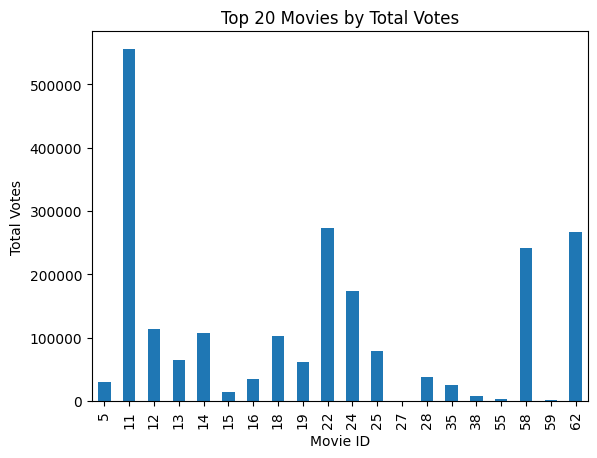

In [72]:
# Bar Chart
grouped['sum'].head(20).plot(kind='bar')
plt.title('Top 20 Movies by Total Votes')
plt.xlabel('Movie ID')
plt.ylabel('Total Votes')
plt.show()

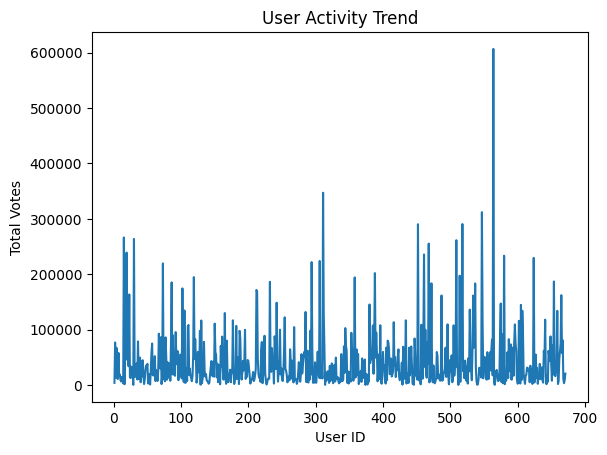

In [73]:
# Line Chart
df.sort_values('userId').groupby('userId')['vote_count'].sum().plot(kind='line')
plt.title('User Activity Trend')
plt.xlabel('User ID')
plt.ylabel('Total Votes')
plt.show()

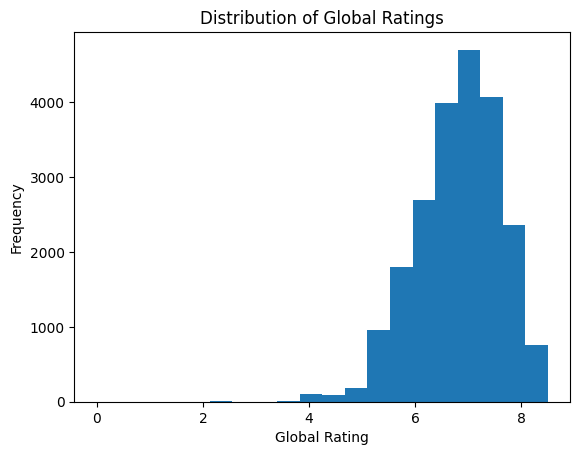

In [74]:
# Histogram
df['vote_average'].plot(kind='hist', bins=20)
plt.title('Distribution of Global Ratings')
plt.xlabel('Global Rating')
plt.show()

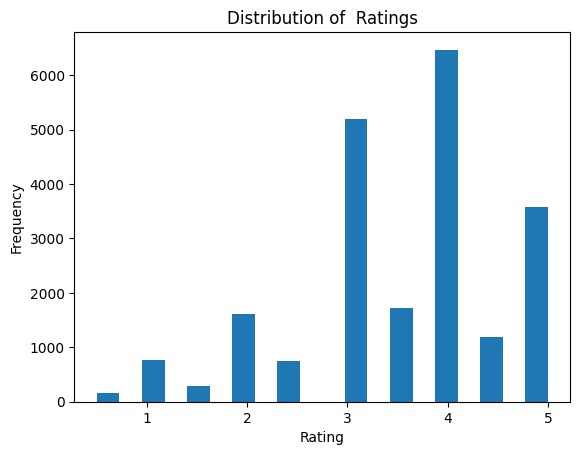

In [78]:
df['rating'].plot(kind='hist', bins=20)
plt.title('Distribution of  Ratings')
plt.xlabel('Rating')
plt.show()

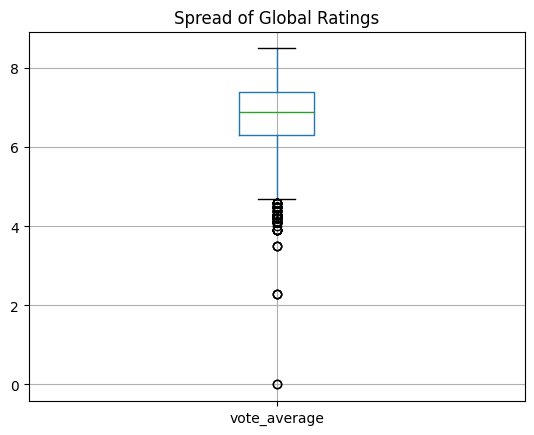

In [75]:
# Boxplot
df.boxplot(column='vote_average')
plt.title('Spread of Global Ratings')
plt.show()

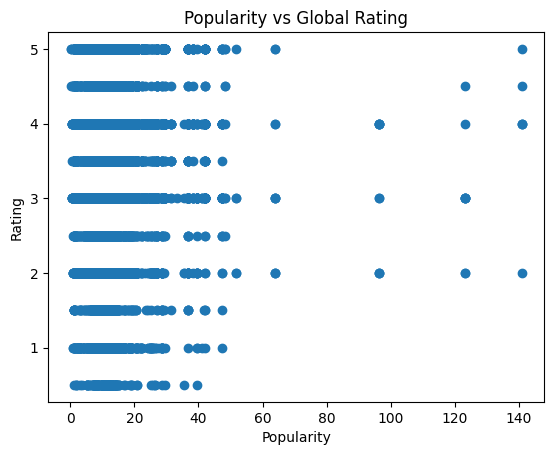

In [ ]:
# Scatter Plot
plt.scatter(df['popularity'], df['vote_average'])
plt.xlabel('Popularity')
plt.ylabel('Global Rating')
plt.title('Popularity vs Global Rating')
plt.show()

**Week 4**

*Done by Paul Rwabajungu*

In [61]:
import pandas as pd
movie=pd.read_excel(r"C:\\Users\\PAUL\\Documents\\final_movie_data.xlsx")
movie.head()

,userId,movieId,rating,timestamp,adult,belongs_to_collection,budget,genres,homepage,imdb_id,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,1,1371,2.5,2009-12-14 02:52:15,False,"{'id': 1575, 'name': 'Rocky Collection', 'post...",17000000,"[{'id': 18, 'name': 'Drama'}]",NaN,tt0084602,...,1982-05-28,270000000,99.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The greatest challenge.,Rocky III,False,6.6,894
1,1,1405,1.0,2009-12-14 02:53:23,False,NaN,546883,"[{'id': 18, 'name': 'Drama'}, {'id': 36, 'name...",NaN,tt0015881,...,1924-12-04,0,140.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Greed,False,7.5,25
2,1,2105,4.0,2009-12-14 02:52:19,False,"{'id': 2806, 'name': 'American Pie Collection'...",11000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,tt0163651,...,1999-07-09,235483004,95.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,There's nothing like your first piece.,American Pie,False,6.4,2358
3,1,2193,2.0,2009-12-14 02:53:18,False,NaN,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://www.crownintlpictures.com/lntitles.html,tt0085980,...,1983-03-04,22587000,97.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,School's out...But Bobby's education has just ...,My Tutor,False,5.8,17
4,1,2294,2.0,2009-12-14 02:51:48,False,NaN,22000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt0261392,...,2001-08-22,33788161,104.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Hollywood had it coming,Jay and Silent Bob Strike Back,False,6.4,491


In [62]:
import ast
#hot-encoding to split the list of genres into separate columns
movie['genres'] = movie['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])
movie['genres_list'] = movie['genres'].apply(lambda x: [i['name'] for i in x])
genres_dummies = movie['genres_list'].explode().str.get_dummies().groupby(level=0).sum()
movie_final = pd.concat([movie, genres_dummies], axis=1)
movie_final = movie_final.drop(['genres', 'genres_list'], axis=1)
movie_final.head()

,userId,movieId,rating,timestamp,adult,belongs_to_collection,budget,homepage,imdb_id,original_language,...,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,1,1371,2.5,2009-12-14 02:52:15,False,"{'id': 1575, 'name': 'Rocky Collection', 'post...",17000000,NaN,tt0084602,en,...,0,0,0,0,0,0,0,0,0,0
1,1,1405,1.0,2009-12-14 02:53:23,False,NaN,546883,NaN,tt0015881,en,...,1,0,0,0,0,0,0,0,0,0
2,1,2105,4.0,2009-12-14 02:52:19,False,"{'id': 2806, 'name': 'American Pie Collection'...",11000000,NaN,tt0163651,en,...,0,0,0,0,1,0,0,0,0,0
3,1,2193,2.0,2009-12-14 02:53:18,False,NaN,0,http://www.crownintlpictures.com/lntitles.html,tt0085980,en,...,0,0,0,0,1,0,0,0,0,0
4,1,2294,2.0,2009-12-14 02:51:48,False,NaN,22000000,NaN,tt0261392,en,...,0,0,0,0,0,0,0,0,0,0


In [63]:
movie.drop(columns=["title","production_companies","production_countries","adult","belongs_to_collection","poster_path","homepage","imdb_id","original_language","original_title","overview","spoken_languages","status","tagline","video"],inplace=True,errors="ignore")
movie.tail()

,userId,movieId,rating,timestamp,budget,genres,popularity,release_date,revenue,runtime,vote_average,vote_count,genres_list
44984,671,4995,4.0,2003-09-30 03:12:17,15000000,"[{'id': 18, 'name': 'Drama'}]",7.595679,1997-09-11,43101594,155.0,7.5,812,[Drama]
44985,671,5816,4.0,2003-10-02 16:26:03,0,"[{'id': 35, 'name': 'Comedy'}]",4.714910,2006-09-28,0,95.0,6.3,8,[Comedy]
44986,671,5902,3.5,2003-09-22 15:45:07,22000000,"[{'id': 18, 'name': 'Drama'}, {'id': 36, 'name...",7.719173,1977-06-15,50750000,175.0,7.0,210,"[Drama, History, War]"
44987,671,5991,4.5,2003-09-22 15:43:07,0,"[{'id': 18, 'name': 'Drama'}]",3.553763,1924-12-23,0,90.0,7.7,63,[Drama]
44988,671,5995,4.0,2003-10-22 03:23:34,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",0.768593,2003-07-31,0,105.0,4.0,5,"[Comedy, Drama]"


In [64]:
import numpy as np
movie_final['budget'] = movie_final['budget'].replace(0, np.nan)
movie_final['revenue'] = movie_final['revenue'].replace(0, np.nan)
movie_final_clean = movie_final.dropna(subset=['budget', 'revenue',])
movie_final_clean.head()

,userId,movieId,rating,timestamp,adult,belongs_to_collection,budget,homepage,imdb_id,original_language,...,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,1,1371,2.5,2009-12-14 02:52:15,False,"{'id': 1575, 'name': 'Rocky Collection', 'post...",17000000.0,NaN,tt0084602,en,...,0,0,0,0,0,0,0,0,0,0
2,1,2105,4.0,2009-12-14 02:52:19,False,"{'id': 2806, 'name': 'American Pie Collection'...",11000000.0,NaN,tt0163651,en,...,0,0,0,0,1,0,0,0,0,0
4,1,2294,2.0,2009-12-14 02:51:48,False,NaN,22000000.0,NaN,tt0261392,en,...,0,0,0,0,0,0,0,0,0,0
7,2,62,3.0,1996-06-21 11:15:49,False,"{'id': 4438, 'name': 'The Space Odyssey Series...",10500000.0,NaN,tt0062622,en,...,0,0,0,1,0,1,0,0,0,0
9,2,144,3.0,1996-06-21 11:20:16,False,NaN,2500000.0,http://www.wim-wenders.com/movies/movies_spec/...,tt0093191,de,...,0,0,0,0,1,0,0,0,0,0


In [65]:
# 1. Runtime: Fix the zeros
movie_final_clean['runtime'] = movie_final_clean['runtime'].replace(0, movie_final_clean['runtime'].median())
# 2. Release Date: Get the Year
movie_final_clean['release_date'] = pd.to_datetime(movie_final_clean['release_date'], errors='coerce')
movie_final_clean['release_year'] = movie_final_clean['release_date'].dt.year
# 3. Timestamp: Get the Hour or Day of Week
movie_final_clean['rating_datetime'] = pd.to_datetime(movie_final_clean['timestamp'], unit='s')
movie_final_clean['day_of_week'] = movie_final_clean['rating_datetime'].dt.dayofweek # 0=Monday, 6=Sunday
movie_final_clean['hour_of_day'] = movie_final_clean['rating_datetime'].dt.hour
movie_final_clean.head()

,userId,movieId,rating,timestamp,adult,belongs_to_collection,budget,homepage,imdb_id,original_language,...,Romance,Science Fiction,TV Movie,Thriller,War,Western,release_year,rating_datetime,day_of_week,hour_of_day
0,1,1371,2.5,2009-12-14 02:52:15,False,"{'id': 1575, 'name': 'Rocky Collection', 'post...",17000000.0,NaN,tt0084602,en,...,0,0,0,0,0,0,1982,2009-12-14 02:52:15,0,2
2,1,2105,4.0,2009-12-14 02:52:19,False,"{'id': 2806, 'name': 'American Pie Collection'...",11000000.0,NaN,tt0163651,en,...,1,0,0,0,0,0,1999,2009-12-14 02:52:19,0,2
4,1,2294,2.0,2009-12-14 02:51:48,False,NaN,22000000.0,NaN,tt0261392,en,...,0,0,0,0,0,0,2001,2009-12-14 02:51:48,0,2
7,2,62,3.0,1996-06-21 11:15:49,False,"{'id': 4438, 'name': 'The Space Odyssey Series...",10500000.0,NaN,tt0062622,en,...,0,1,0,0,0,0,1968,1996-06-21 11:15:49,4,11
9,2,144,3.0,1996-06-21 11:20:16,False,NaN,2500000.0,http://www.wim-wenders.com/movies/movies_spec/...,tt0093191,de,...,1,0,0,0,0,0,1987,1996-06-21 11:20:16,4,11


In [66]:
import pandas as pd
# 1. Calculate the average rating for every unique UserID
# By creating a 'dictionary' where the index is the UserID and the value is their average
user_means = movie_final_clean.groupby('userId')['rating'].mean()
# 2. Map those averages back to your original dataframe
movie_final_clean['user_mean_rating'] = movie_final_clean['userId'].map(user_means)
# 3. Calculating the number of movies each user has rated
user_counts = movie_final_clean.groupby('userId')['rating'].count()
movie_final_clean['user_rating_count'] = movie_final_clean['userId'].map(user_counts)
movie_final_clean.head(10)

,userId,movieId,rating,timestamp,adult,belongs_to_collection,budget,homepage,imdb_id,original_language,...,TV Movie,Thriller,War,Western,release_year,rating_datetime,day_of_week,hour_of_day,user_mean_rating,user_rating_count
0,1,1371,2.5,2009-12-14 02:52:15,False,"{'id': 1575, 'name': 'Rocky Collection', 'post...",17000000.0,NaN,tt0084602,en,...,0,0,0,0,1982,2009-12-14 02:52:15,0,2,2.833333,3
2,1,2105,4.0,2009-12-14 02:52:19,False,"{'id': 2806, 'name': 'American Pie Collection'...",11000000.0,NaN,tt0163651,en,...,0,0,0,0,1999,2009-12-14 02:52:19,0,2,2.833333,3
4,1,2294,2.0,2009-12-14 02:51:48,False,NaN,22000000.0,NaN,tt0261392,en,...,0,0,0,0,2001,2009-12-14 02:51:48,0,2,2.833333,3
7,2,62,3.0,1996-06-21 11:15:49,False,"{'id': 4438, 'name': 'The Space Odyssey Series...",10500000.0,NaN,tt0062622,en,...,0,0,0,0,1968,1996-06-21 11:15:49,4,11,3.450000,40
9,2,144,3.0,1996-06-21 11:20:16,False,NaN,2500000.0,http://www.wim-wenders.com/movies/movies_spec/...,tt0093191,de,...,0,0,0,0,1987,1996-06-21 11:20:16,4,11,3.450000,40
10,2,150,5.0,1996-06-21 11:09:55,False,"{'id': 93295, 'name': '48 Hrs. Collection', 'p...",12000000.0,NaN,tt0083511,en,...,0,1,0,0,1982,1996-06-21 11:09:55,4,11,3.450000,40
11,2,153,4.0,1996-06-21 11:10:41,False,NaN,4000000.0,NaN,tt0335266,en,...,0,0,0,0,2003,1996-06-21 11:10:41,4,11,3.450000,40
12,2,161,3.0,1996-06-21 11:11:33,False,"{'id': 304, 'name': ""Ocean's Collection"", 'pos...",85000000.0,http://www.warnerbros.co.uk/movies/oceans-eleven,tt0240772,en,...,0,1,0,0,2001,1996-06-21 11:11:33,4,11,3.450000,40
13,2,165,3.0,1996-06-21 11:10:41,False,"{'id': 264, 'name': 'Back to the Future Collec...",40000000.0,http://www.backtothefuture.com/movies/backtoth...,tt0096874,en,...,0,0,0,0,1989,1996-06-21 11:10:41,4,11,3.450000,40
14,2,168,3.0,1996-06-21 11:15:10,False,"{'id': 151, 'name': 'Star Trek: The Original S...",24000000.0,NaN,tt0092007,en,...,0,0,0,0,1986,1996-06-21 11:15:10,4,11,3.450000,40


In [67]:
import numpy as np
import pandas as pd
# 2. Applying the Log Transformation to cater for the differences in scale and to reduce skewness
movie_final_clean['budget_log'] = np.log1p(movie_final_clean['budget'])
movie_final_clean['revenue_log'] = np.log1p(movie_final_clean['revenue'])
print(movie_final_clean[['budget', 'budget_log', 'revenue', 'revenue_log']].head())

       budget  budget_log      revenue  revenue_log
0  17000000.0   16.648724  270000000.0    19.413933
2  11000000.0   16.213406  235483004.0    19.277149
4  22000000.0   16.906553   33788161.0    17.335621
7  10500000.0   16.166886   68700000.0    18.045260
9   2500000.0   14.731802    3200000.0    14.978662


In [68]:
movie_final_clean.info()

<class 'pandas.DataFrame'>
Index: 21723 entries, 0 to 44986
Data columns (total 54 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   userId                 21723 non-null  int64         
 1   movieId                21723 non-null  int64         
 2   rating                 21723 non-null  float64       
 3   timestamp              21723 non-null  datetime64[us]
 4   adult                  21723 non-null  bool          
 5   belongs_to_collection  7552 non-null   str           
 6   budget                 21723 non-null  float64       
 7   homepage               7544 non-null   str           
 8   imdb_id                21723 non-null  str           
 9   original_language      21723 non-null  str           
 10  original_title         21723 non-null  str           
 11  overview               21723 non-null  str           
 12  popularity             21723 non-null  float64       
 13  poster_path      

In [69]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
# 1. Feature Selection (Numbers & One-Hot Genres)
# Using the log-transformed budget and revenue and the user's mean rating
X = pd.concat([
    movie_final_clean[['budget_log', 'revenue_log', 'popularity', 'runtime',
                       'vote_average', 'vote_count', 'user_mean_rating']],
    genres_dummies.loc[movie_final_clean.index]
], axis=1)
y = movie_final_clean['rating']
# 2. Splitting into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 3. Creating the Model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
# 4. Training the Model
rf_model.fit(X_train, y_train)
# 5. Prediction and Evaluation
y_pred = rf_model.predict(X_test)
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")

Mean Squared Error: 0.8241578893079555


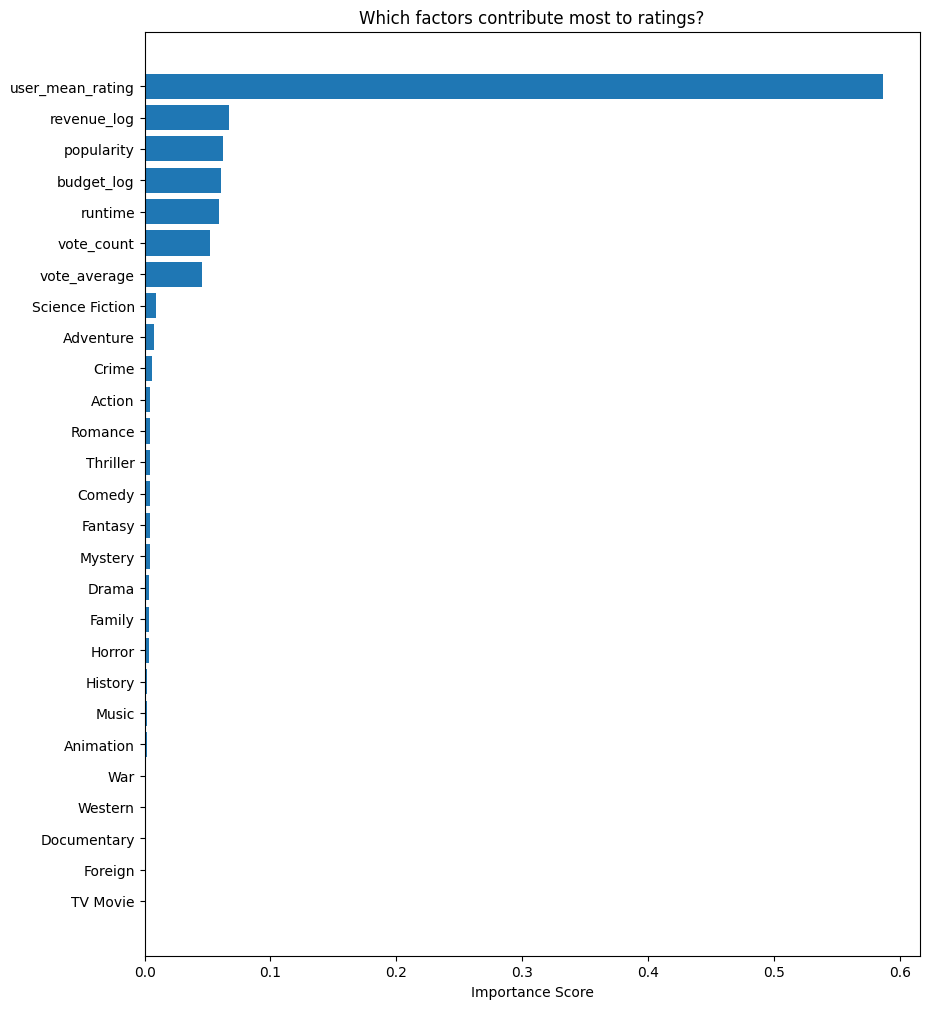

             Feature  Importance
6   user_mean_rating    0.586259
1        revenue_log    0.066763
2         popularity    0.062519
0         budget_log    0.060869
3            runtime    0.058704
5         vote_count    0.052271
4       vote_average    0.045891
22   Science Fiction    0.009015
8          Adventure    0.007443
11             Crime    0.005534
7             Action    0.004668
21           Romance    0.004375
24          Thriller    0.004177
10            Comedy    0.004076
15           Fantasy    0.004036
20           Mystery    0.003958
13             Drama    0.003477
14            Family    0.003354
18            Horror    0.003213
17           History    0.002107
19             Music    0.001827
9          Animation    0.001708
25               War    0.001425
26           Western    0.001286
12       Documentary    0.001045
16           Foreign    0.000000
23          TV Movie    0.000000


In [70]:
import pandas as pd
import matplotlib.pyplot as plt
# 1. Getting the importance scores from your trained model
importances = rf_model.feature_importances_
# 2. Matching them with your column names
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
# 3. Sorting them from highest to lowest
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
# 4. Plotting the top 10 to see it visually
plt.figure(figsize=(10, 12))
plt.barh(feature_importance_df['Feature'].head(1000), feature_importance_df['Importance'].head(1000))
plt.xlabel('Importance Score')
plt.title('Which factors contribute most to ratings?')
plt.gca().invert_yaxis() 
plt.show()
print(feature_importance_df.head(1000))